 Dataset loaded successfully!

    id  age gender     track  days_attended  score
0  001   19      F      Tech              2      4
1  002   22      M  Business              5      8
2  003   20      F  Creative              1      3
3  004   24      M      Tech              3      6
4  005   21      F  Business              4      7
5  006   23      M  Creative              1      2
6  007   18      F      Tech              2      5
7  008   25      M  Business              5      9
8  009   20      F  Creative              2      4
9  010   22      M      Tech              4      7

────────────────────────────────────────────────────────────
 Q1 · Which track has the highest dropout rate?
────────────────────────────────────────────────────────────
track
Business     33.3
Creative    100.0
Tech        100.0
Name: dropout, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_1308\3457119796.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dropout_by_track.index, y=dropout_by_track.values, palette='viridis')


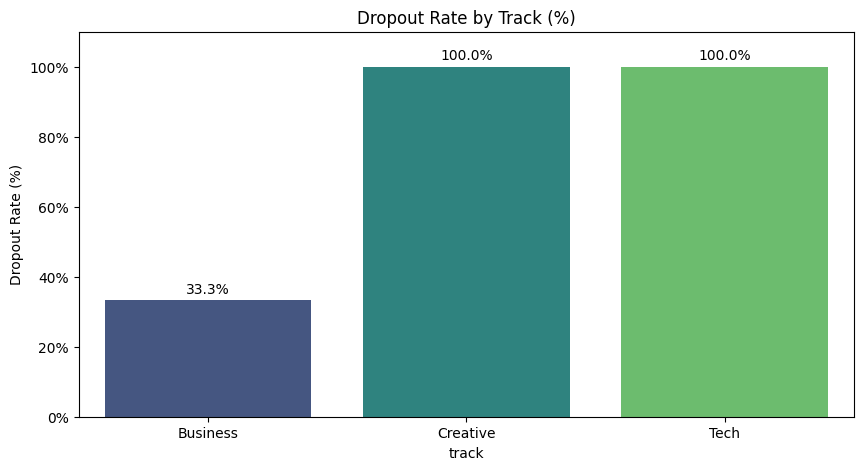


────────────────────────────────────────────────────────────
 Q2 · Relationship between Days Attended and Score
────────────────────────────────────────────────────────────
Pearson Correlation: 0.978 → Strong positive relationship


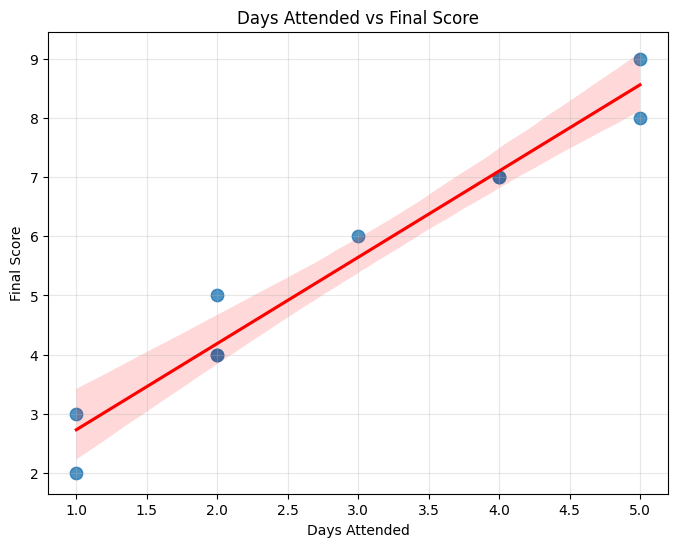


────────────────────────────────────────────────────────────
 Q3 · Does Gender affect Engagement?
────────────────────────────────────────────────────────────
        days_attended  score
gender                      
F                 2.2    4.6
M                 3.6    6.4

Independent T-test (Gender vs Days Attended):
t-statistic = 1.565 | p-value = 0.1621
→ No statistically significant difference


C:\Users\Dell\AppData\Local\Temp\ipykernel_1308\3457119796.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='days_attended', data=df, palette='Set2')
C:\Users\Dell\AppData\Local\Temp\ipykernel_1308\3457119796.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='score', data=df, palette='Set2')


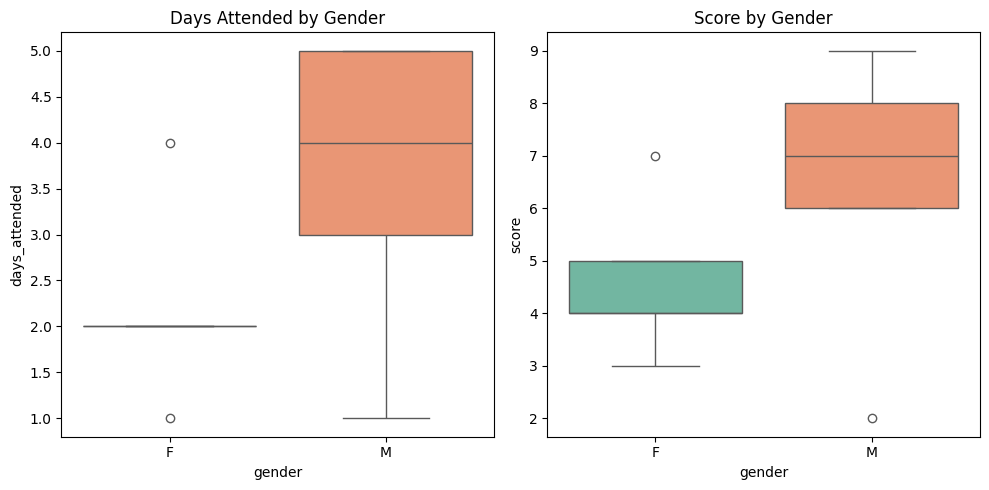


────────────────────────────────────────────────────────────
 Q4 · Which track has the highest average engagement?
────────────────────────────────────────────────────────────
track
Business    4.67
Creative    1.33
Tech        2.75
Name: days_attended, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_1308\3457119796.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=track_engagement.index, y=track_engagement.values, palette='mako')


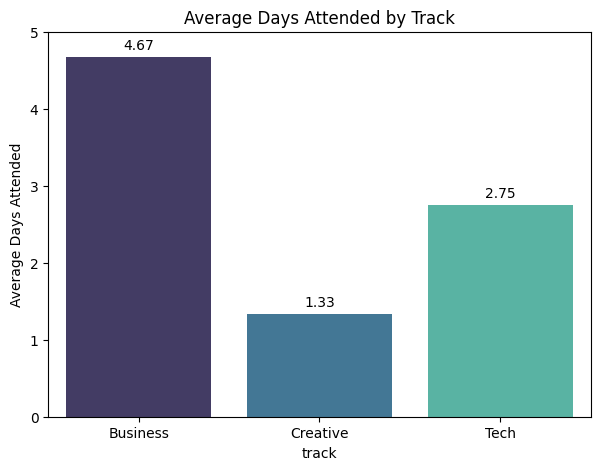


One-way ANOVA (Track vs Days Attended):
F-statistic = 14.414 | p-value = 0.0033
→ Significant differences between tracks

────────────────────────────────────────────────────────────
 Q5 · Advanced Insights & Predictive Strength
────────────────────────────────────────────────────────────
Correlation Matrix:
                  age  days_attended  score
age            1.000          0.506  0.462
days_attended  0.506          1.000  0.978
score          0.462          0.978  1.000


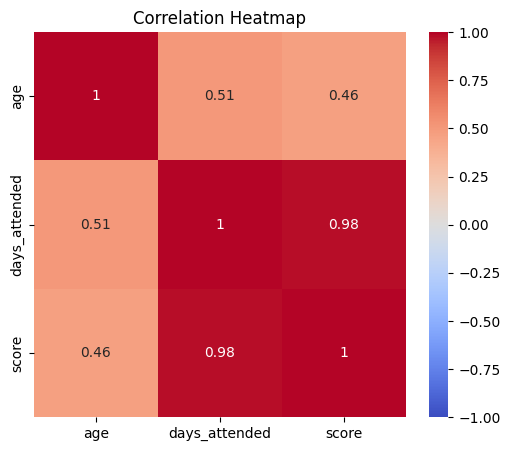

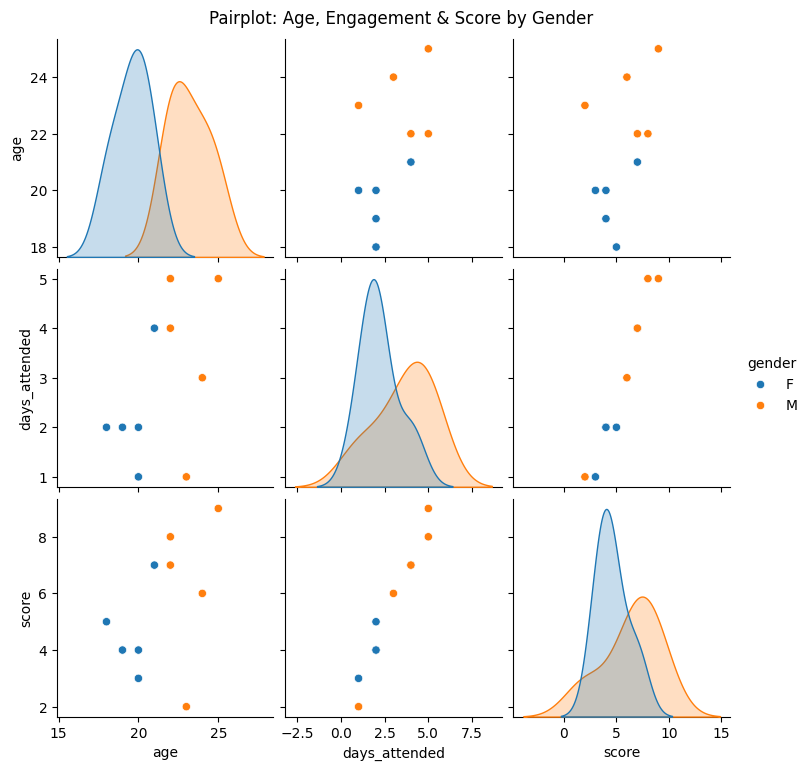


────────────────────────────────────────────────────────────
 SUMMARY - Engagement Drop Crisis
────────────────────────────────────────────────────────────
• Highest dropout          → Creative track
• Strongest predictor      → Days attended (r = 0.98 )
• Gender difference        → Males attended more days on average
• Best performing track    → Business
• Statistical notes:
   - Gender t-test p-value: 0.1621
   - Track ANOVA p-value:  0.0033

Full analysis complete with statistical tests and enhanced visualizations!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats

#Dataset or participants
participants = [
    {"id": "001", "age": 19, "gender": "F", "track": "Tech", "days": [1,1,0,0,0], "score": 4},
    {"id": "002", "age": 22, "gender": "M", "track": "Business", "days": [1,1,1,1,1], "score": 8},
    {"id": "003", "age": 20, "gender": "F", "track": "Creative", "days": [1,0,0,0,0], "score": 3},
    {"id": "004", "age": 24, "gender": "M", "track": "Tech", "days": [1,1,1,0,0], "score": 6},
    {"id": "005", "age": 21, "gender": "F", "track": "Business", "days": [1,1,1,1,0], "score": 7},
    {"id": "006", "age": 23, "gender": "M", "track": "Creative", "days": [1,0,0,0,0], "score": 2},
    {"id": "007", "age": 18, "gender": "F", "track": "Tech", "days": [1,1,0,0,0], "score": 5},
    {"id": "008", "age": 25, "gender": "M", "track": "Business", "days": [1,1,1,1,1], "score": 9},
    {"id": "009", "age": 20, "gender": "F", "track": "Creative", "days": [1,1,0,0,0], "score": 4},
    {"id": "010", "age": 22, "gender": "M", "track": "Tech", "days": [1,1,1,1,0], "score": 7},
]

# DataFrame
df = pd.DataFrame(participants)
days_df = pd.DataFrame(df['days'].tolist(), columns=["Day1", "Day2", "Day3", "Day4", "Day5"])
df = pd.concat([df.drop('days', axis=1), days_df], axis=1)

df['days_attended'] = df[["Day1", "Day2", "Day3", "Day4", "Day5"]].sum(axis=1)
df['dropout'] = (df['days_attended'] < 5).astype(int)

print(" Dataset loaded successfully!\n")
print(df[['id', 'age', 'gender', 'track', 'days_attended', 'score']])

# Helper function for section headers
def section(title):
    print("\n" + "─" * 60)
    print(f" {title}")
    print("─" * 60)

#Q1: Dropout rate by track
section("Q1 · Which track has the highest dropout rate?")

dropout_by_track = df.groupby('track')['dropout'].mean() * 100
print(dropout_by_track.round(1))

plt.figure(figsize=(10, 5))
sns.barplot(x=dropout_by_track.index, y=dropout_by_track.values, palette='viridis')
plt.title('Dropout Rate by Track (%)')
plt.ylabel('Dropout Rate (%)')
plt.ylim(0, 110)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(dropout_by_track):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=10)
plt.show()

#Q2: Relationship between days attended and score
section("Q2 · Relationship between Days Attended and Score")

corr = df['days_attended'].corr(df['score'])
print(f"Pearson Correlation: {corr:.3f} → Strong positive relationship")

plt.figure(figsize=(8, 6))
sns.regplot(x='days_attended', y='score', data=df, scatter_kws={'s': 80}, line_kws={'color': 'red'})
plt.title('Days Attended vs Final Score')
plt.xlabel('Days Attended')
plt.ylabel('Final Score')
plt.grid(True, alpha=0.3)
plt.show()

#Q3: Gender effect on engagement
section("Q3 · Does Gender affect Engagement?")

gender_stats = df.groupby('gender')[['days_attended', 'score']].mean().round(2)
print(gender_stats)

# T-test for statistical significance
male_days = df[df['gender'] == 'M']['days_attended']
female_days = df[df['gender'] == 'F']['days_attended']
t_stat, p_val = stats.ttest_ind(male_days, female_days, equal_var=False)

print(f"\nIndependent T-test (Gender vs Days Attended):")
print(f"t-statistic = {t_stat:.3f} | p-value = {p_val:.4f}")
if p_val < 0.05:
    print("→ Statistically significant difference (p < 0.05)")
else:
    print("→ No statistically significant difference")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='gender', y='days_attended', data=df, palette='Set2')
plt.title('Days Attended by Gender')
plt.subplot(1, 2, 2)
sns.boxplot(x='gender', y='score', data=df, palette='Set2')
plt.title('Score by Gender')
plt.tight_layout()
plt.show()

#Q4: Track with highest average engagement
section("Q4 · Which track has the highest average engagement?")

track_engagement = df.groupby('track')['days_attended'].mean().round(2)
print(track_engagement)

plt.figure(figsize=(7, 5))
sns.barplot(x=track_engagement.index, y=track_engagement.values, palette='mako')
plt.title('Average Days Attended by Track')
plt.ylabel('Average Days Attended')
plt.ylim(0, 5)
for i, v in enumerate(track_engagement):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center')
plt.show()

# ANOVA test
tech = df[df['track']=='Tech']['days_attended']
bus = df[df['track']=='Business']['days_attended']
cre = df[df['track']=='Creative']['days_attended']
f_stat, anova_p = stats.f_oneway(tech, bus, cre)

print(f"\nOne-way ANOVA (Track vs Days Attended):")
print(f"F-statistic = {f_stat:.3f} | p-value = {anova_p:.4f}")
if anova_p < 0.05:
    print("→ Significant differences between tracks")
else:
    print("→ No significant differences between tracks")

#Q5: Correlations & Advanced Insights
section("Q5 · Advanced Insights & Predictive Strength")

# Correlation matrix + heatmap
corr_matrix = df[['age', 'days_attended', 'score']].corr()
print("Correlation Matrix:\n", corr_matrix.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

# Pairplot
sns.pairplot(df[['age', 'days_attended', 'score', 'gender']], hue='gender', diag_kind='kde')
plt.suptitle('Pairplot: Age, Engagement & Score by Gender', y=1.02)
plt.show()

# Summary
section("SUMMARY - Engagement Drop Crisis")
print("• Highest dropout          → Creative track")
print("• Strongest predictor      → Days attended (r =", round(corr, 2), ")")
print("• Gender difference        → Males attended more days on average")
print("• Best performing track    → Business")
print("• Statistical notes:")
print(f"   - Gender t-test p-value: {p_val:.4f}")
print(f"   - Track ANOVA p-value:  {anova_p:.4f}")
